# Chicago Food Inspection Analysis

## 1. Topic / Business Question

_Formulate a topic or business questions you want to investigate. Describe your topic and the benefit for others or stakeholders. What are your findings and conclusions? How does your analysis address the topic or business question(s)?_

### Business Problem
Can we identify patterns in food inspection results and predict which establishments are at higher risk of failing an inspection?

### Stakeholders / Benefit
- Health authorities → better allocation of inspection resources
- Restaurant owners → understand risk drivers
- City of Chicago → improve public health safety

## Objectives
- Identify key risk factors for inspection failure
- Explore patterns in violations and facility types
- Build foundation for predictive risk modeling

# 2. Data Collection, Quality, and Pre-Processing

_What data are you using, and how did you acquire it? In what quality is the data (missing values, outliers, errors, duplicates, ...) and do you need to pre-process it?_

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from rapidfuzz import fuzz, process


In [75]:
#
url = "https://data.cityofchicago.org/resource/4ijn-s7e5.csv?$limit=50000"

df = pd.read_csv(url)

df.shape

(50000, 17)

In [76]:
df.head()

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
0,2638766,FIFTH CITY CHILD DEVELOPMENT,FIFTH CITY CHILD DEVELOPMENT,2215558.0,Children's Services Facility,Risk 1 (High),3411 W FIFTH AVE,CHICAGO,IL,60624.0,2026-06-22T00:00:00.000,License,Pass,NaN,41.876795,-87.711289,"\n, \n(41.876795310698334, -87.71128878015891)"
1,2638772,BEST SUB INCORPORATED,BEST SUB INCORPORATED,1194826.0,Restaurant,Risk 1 (High),3156 W CHICAGO AVE,CHICAGO,IL,60622.0,2026-06-22T00:00:00.000,Canvass,Fail,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.895665,-87.706411,"\n, \n(41.89566455251599, -87.7064114773248)"
2,2638770,HOT WINGS & BEST SUB,HOT WINGS & BEST SUB,3086592.0,Restaurant,Risk 1 (High),3156 W CHICAGO AVE,CHICAGO,IL,60622.0,2026-06-22T00:00:00.000,License,Not Ready,NaN,41.895665,-87.706411,"\n, \n(41.89566455251599, -87.7064114773248)"
3,2638787,BREAKTHROUGH BEGINNERS,BREAKTHROUGH BEGINNERS,2379693.0,Children's Services Facility,Risk 1 (High),3219 W CARROLL AVE,CHICAGO,IL,60624.0,2026-06-22T00:00:00.000,License,Pass,36. THERMOMETERS PROVIDED & ACCURATE - Comment...,41.887402,-87.707086,"\n, \n(41.887402155077424, -87.70708560385715)"
4,2638765,NAGUARA AREPAS,NAGUARA AREPAS,2951624.0,Restaurant,Risk 1 (High),2525 N LARAMIE AVE,CHICAGO,IL,60639.0,2026-06-22T00:00:00.000,Canvass,Out of Business,NaN,41.926829,-87.756099,"\n, \n(41.92682881739574, -87.75609869666849)"


### Dataset Structure

In [77]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   inspection_id    50000 non-null  int64  
 1   dba_name         50000 non-null  str    
 2   aka_name         49955 non-null  str    
 3   license_         49998 non-null  float64
 4   facility_type    49704 non-null  str    
 5   risk             49986 non-null  str    
 6   address          50000 non-null  str    
 7   city             49950 non-null  str    
 8   state            49980 non-null  str    
 9   zip              49998 non-null  float64
 10  inspection_date  50000 non-null  str    
 11  inspection_type  50000 non-null  str    
 12  results          50000 non-null  str    
 13  violations       33861 non-null  str    
 14  latitude         49817 non-null  float64
 15  longitude        49817 non-null  float64
 16  location         49817 non-null  str    
dtypes: float64(4), int64(1)

In [78]:
df.describe(include="all")

,inspection_id,dba_name,aka_name,license_,facility_type,risk,address,city,state,zip,inspection_date,inspection_type,results,violations,latitude,longitude,location
count,5.000000e+04,50000,49955,4.999800e+04,49704,49986,50000,49950,49980,49998.000000,50000,50000,50000,33861,49817.000000,49817.000000,49817
unique,NaN,13422,12941,NaN,191,4,19691,35,5,NaN,658,15,7,33533,NaN,NaN,19410
top,NaN,SUBWAY,SUBWAY,NaN,Restaurant,Risk 1 (High),11601 W TOUHY AVE,CHICAGO,IL,NaN,2024-10-08T00:00:00.000,Canvass,Pass,58. ALLERGEN TRAINING AS REQUIRED - Comments: ...,NaN,NaN,"\n, \n(42.00875076599798, -87.90687413400109)"
freq,NaN,534,648,NaN,35629,40156,463,49755,49969,NaN,125,25364,26544,13,NaN,NaN,467
mean,2.611052e+06,NaN,NaN,2.251062e+06,NaN,NaN,NaN,NaN,NaN,60629.396676,NaN,NaN,NaN,NaN,41.879432,-87.675341,NaN
std,1.583229e+04,NaN,NaN,9.327818e+05,NaN,NaN,NaN,NaN,NaN,290.395043,NaN,NaN,NaN,NaN,0.079323,0.059007,NaN
min,2.583786e+06,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,46322.000000,NaN,NaN,NaN,NaN,41.644670,-87.906874,NaN
25%,2.596418e+06,NaN,NaN,2.068654e+06,NaN,NaN,NaN,NaN,NaN,60614.000000,NaN,NaN,NaN,NaN,41.835336,-87.706253,NaN
50%,2.611982e+06,NaN,NaN,2.578703e+06,NaN,NaN,NaN,NaN,NaN,60625.000000,NaN,NaN,NaN,NaN,41.891195,-87.664663,NaN
75%,2.624575e+06,NaN,NaN,2.896080e+06,NaN,NaN,NaN,NaN,NaN,60643.000000,NaN,NaN,NaN,NaN,41.937042,-87.634289,NaN


In [79]:
df.columns

Index(['inspection_id', 'dba_name', 'aka_name', 'license_', 'facility_type',
       'risk', 'address', 'city', 'state', 'zip', 'inspection_date',
       'inspection_type', 'results', 'violations', 'latitude', 'longitude',
       'location'],
      dtype='str')

In [80]:
df.dtypes

inspection_id        int64
dba_name               str
aka_name               str
license_           float64
facility_type          str
risk                   str
address                str
city                   str
state                  str
zip                float64
inspection_date        str
inspection_type        str
results                str
violations             str
latitude           float64
longitude          float64
location               str
dtype: object

The dataset contains numerical, categorical, and textual variables.
The most important target-related variable is `results`, while `violations` contains unstructured text.
license eindeutige Identifikation des Restaurants

### Missing Values Analysis

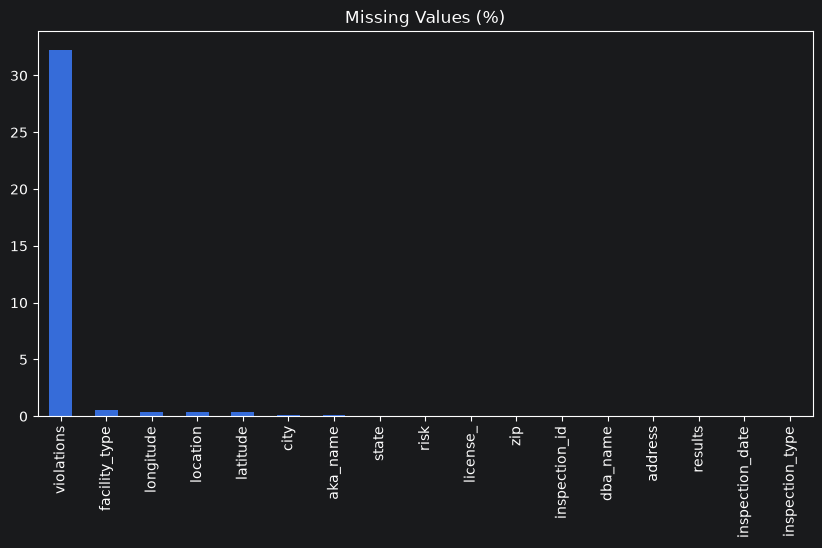

In [81]:
missing = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).sort_values(ascending=False)

missing_percent.plot(kind="bar", figsize=(10,5))
plt.title("Missing Values (%)")
plt.show()

### Data Cleaning

In [82]:
df["violations_clean"] = df["violations"].fillna("NO_VIOLATION_RECORDED")
df["facility_type"] = df["facility_type"].fillna("UNKNOWN")
df["city"] = df["city"].fillna("Unknown")

### Data Features

In [83]:
df["inspection_date"] = pd.to_datetime(df["inspection_date"], errors="coerce")

df["year"] = df["inspection_date"].dt.year
df["month"] = df["inspection_date"].dt.month
df["weekday"] = df["inspection_date"].dt.day_name()

### Duplicates

In [84]:
df.duplicated().sum()

np.int64(0)

Missing values in "violations" are not completely random.
They are strongly associated with inspection outcomes (Pass, Out of Business, No Entry).
This indicates missingness is **informative**, not noise.

## 3. Exploratory Data Analysis and Data Visualization

_Summarize your data by describing it, aggregating it and using tables and plots. What can you tell about your topic/business questions? What insights can you draw from this analysis?_

### Inspection Results Distribution

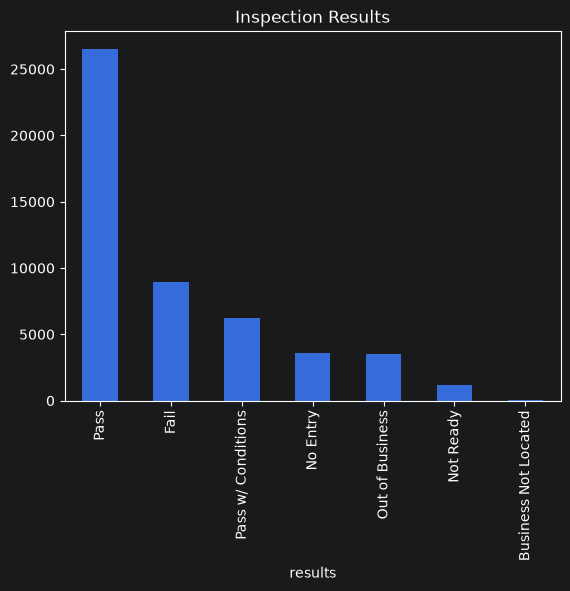

In [85]:
df["results"].value_counts().plot(kind="bar")
plt.title("Inspection Results")
plt.show()

### Risk Categories

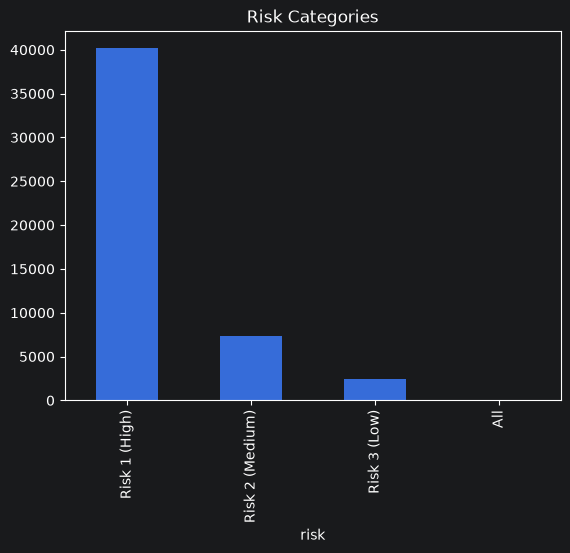

In [86]:
df["risk"].value_counts().plot(kind="bar")
plt.title("Risk Categories")
plt.show()

### Facility Types

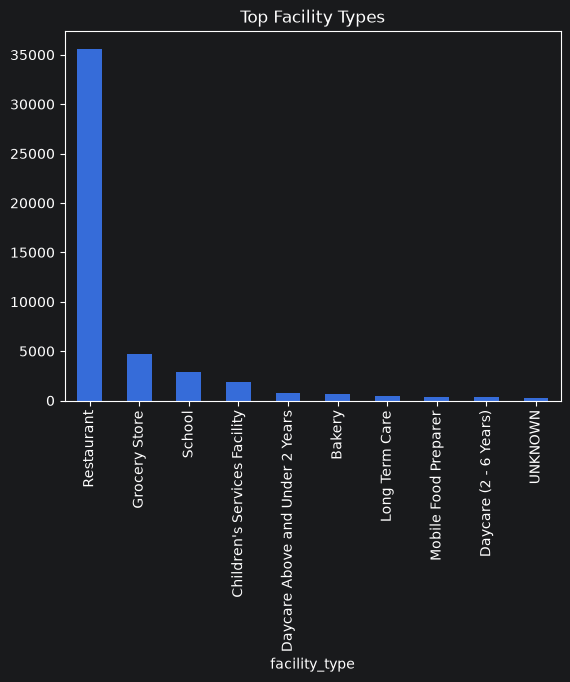

In [87]:
df["facility_type"].value_counts().head(10).plot(kind="bar")
plt.title("Top Facility Types")
plt.show()

### Fail Rate by Facility Type

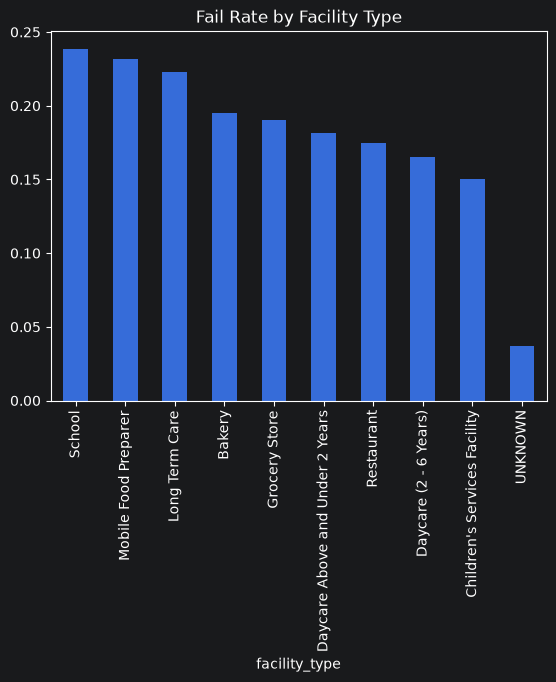

In [88]:
top_types = df["facility_type"].value_counts().head(10).index
df_top = df[df["facility_type"].isin(top_types)]

fail_rate = (
    pd.crosstab(df_top["facility_type"], df_top["results"], normalize="index")
    .get("Fail", 0)
    .sort_values(ascending=False)
)

fail_rate.plot(kind="bar")
plt.title("Fail Rate by Facility Type")
plt.show()

### Temporal Patterns

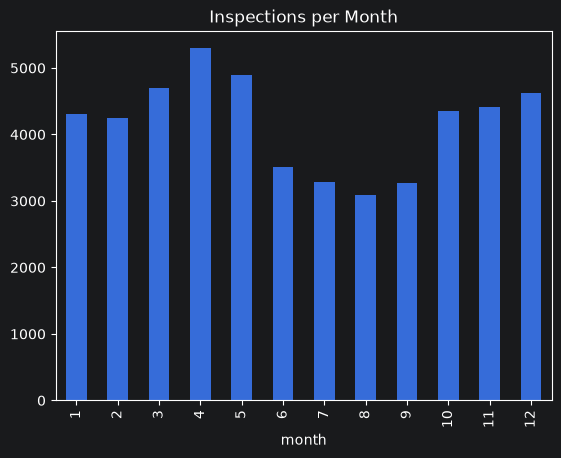

In [89]:
df["month"].value_counts().sort_index().plot(kind="bar")
plt.title("Inspections per Month")
plt.show()

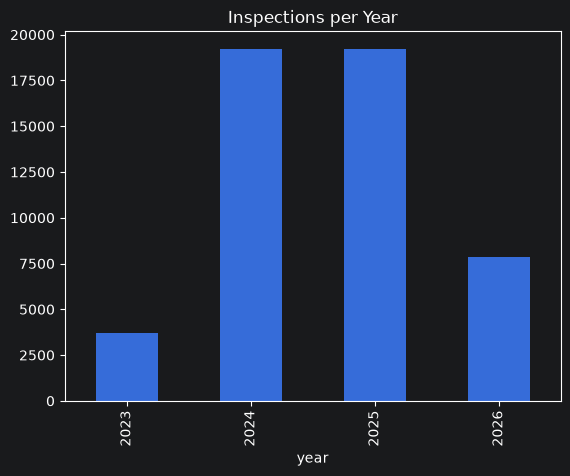

In [90]:
df["year"].value_counts().sort_index().plot(kind="bar")
plt.title("Inspections per Year")
plt.show()

### Zip Code Risk Analysis

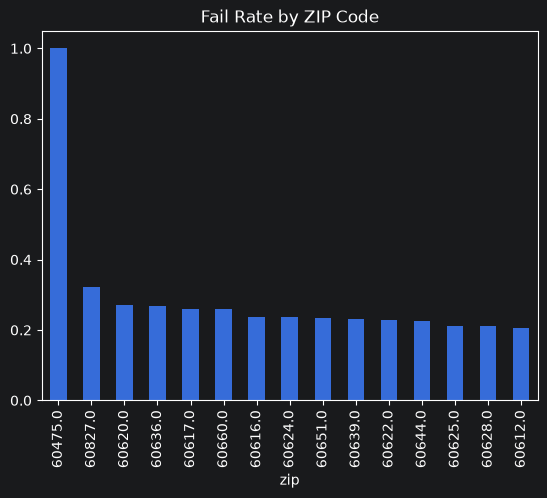

In [91]:
zip_stats = df.groupby("zip").agg(
    total=("inspection_id", "count"),
    fails=("results", lambda x: (x == "Fail").sum())
)

zip_stats["fail_rate"] = zip_stats["fails"] / zip_stats["total"]

zip_stats.sort_values("fail_rate", ascending=False).head(15)["fail_rate"].plot(kind="bar")
plt.title("Fail Rate by ZIP Code")
plt.show()

### Text Analysis (Violations)

In [92]:
text = " ".join(df["violations"].fillna("").astype(str))
words = re.findall(r"\b[a-z]+\b", text.lower())

Counter(words).most_common(20)

[('and', 206843),
 ('to', 155854),
 ('food', 152671),
 ('comments', 152152),
 ('the', 146035),
 ('in', 143614),
 ('instructed', 109292),
 ('observed', 106141),
 ('of', 99535),
 ('clean', 81291),
 ('on', 74481),
 ('maintain', 65628),
 ('at', 63040),
 ('all', 60226),
 ('must', 54376),
 ('properly', 50723),
 ('area', 50169),
 ('prep', 43535),
 ('a', 39646),
 ('installed', 39599)]

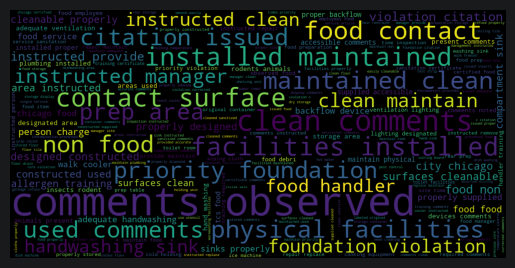

In [93]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

words = [w for w in words if w not in ENGLISH_STOP_WORDS]

wordcloud = WordCloud(width=1000, height=500).generate(" ".join(words))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### Violation Codes

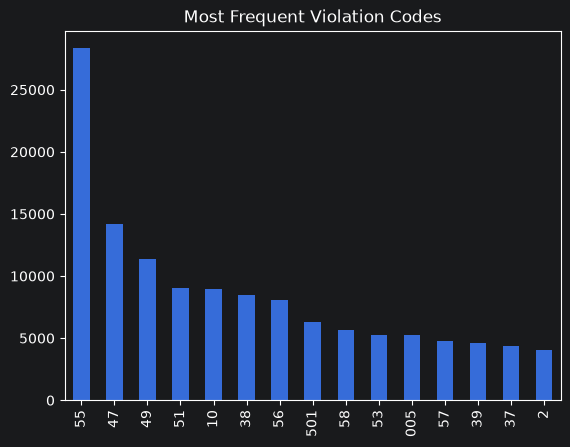

In [94]:
codes = []
for row in df["violations"].dropna():
    codes.extend(re.findall(r"(\d+)\.", row))

pd.Series(codes).value_counts().head(15).plot(kind="bar")
plt.title("Most Frequent Violation Codes")
plt.show()

## Feature Engineering

### Risk Score Encoding

In [95]:
df_clean = df.dropna(subset=["facility_type", "results"])

risk_map = {
    "Fail": 1.0,
    "Pass w/ Conditions": 0.5,
    "Pass": 0.0
}

df_clean["risk_score"] = df_clean["results"].map(risk_map)

### Risk Ranking

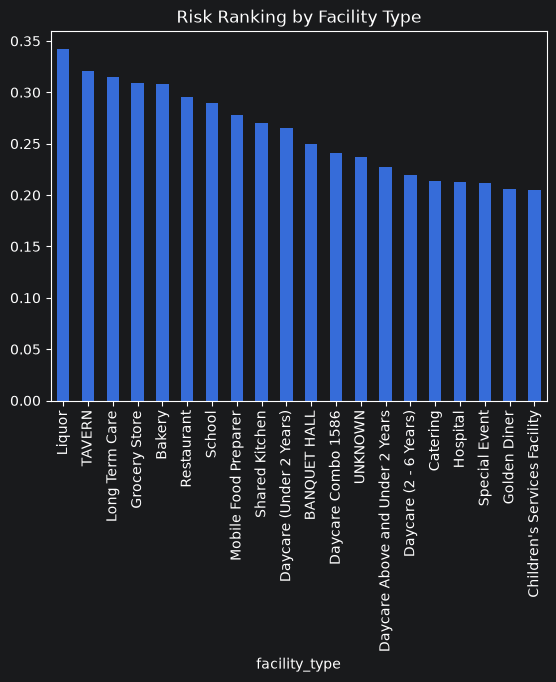

In [96]:
ranking_risk = df_clean.groupby("facility_type")["risk_score"].mean().sort_values(ascending=False)

counts = df_clean["facility_type"].value_counts()
ranking_risk_filtered = ranking_risk[counts >= 30]

ranking_risk_filtered.head(20).plot(kind="bar")
plt.title("Risk Ranking by Facility Type")
plt.show()

### Target Variable

In [97]:
df_ml = df[df["results"].isin(["Pass", "Fail", "Pass w/ Conditions"])].copy()

df_ml["failed"] = (df_ml["results"] == "Fail").astype(int)

df_ml["failed"].value_counts()

failed
0    32787
1     8910
Name: count, dtype: int64

### Violations -> ML Features

In [98]:
from sklearn.preprocessing import MultiLabelBinarizer

def extract_codes(text):
    if pd.isna(text):
        return []
    return re.findall(r"(\d+)\.", text)

df_ml["violation_codes"] = df_ml["violations"].apply(extract_codes)

df_ml["violations_length"] = (
    df_ml["violations"].fillna("").str.len()
)

df_ml["num_violations"] = (
    df_ml["violations"].fillna("").apply(lambda x: x.count("|") + 1 if x != "" else 0)
)

mlb = MultiLabelBinarizer()

violation_matrix = pd.DataFrame(
    mlb.fit_transform(df_ml["violation_codes"]),
    columns=[f"viol_{c}" for c in mlb.classes_],
    index=df_ml.index
)

df_ml = pd.concat([df_ml, violation_matrix], axis=1)

### ML Feature Set

Final Features:
- facility_type
- inspection_type
- zip
- risk
- num_violations
- violation_codes (one-hot encoded)
- violations_length

## Feature Matrix

In [99]:
features = [
    "risk",
    "zip",
    "inspection_type",
    "facility_type",
    "year",
##    "num_violations",
##    "violations_length"
]

X = df_ml[features]
y = df_ml["failed"]

### Encoding

In [100]:
X = pd.get_dummies(X, drop_first=True)

### Train/Test Split

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### XGBoost

In [102]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [103]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.79      0.99      0.88      6558
           1       0.52      0.04      0.08      1782

    accuracy                           0.79      8340
   macro avg       0.66      0.52      0.48      8340
weighted avg       0.73      0.79      0.71      8340

AUC: 0.6882709203792867


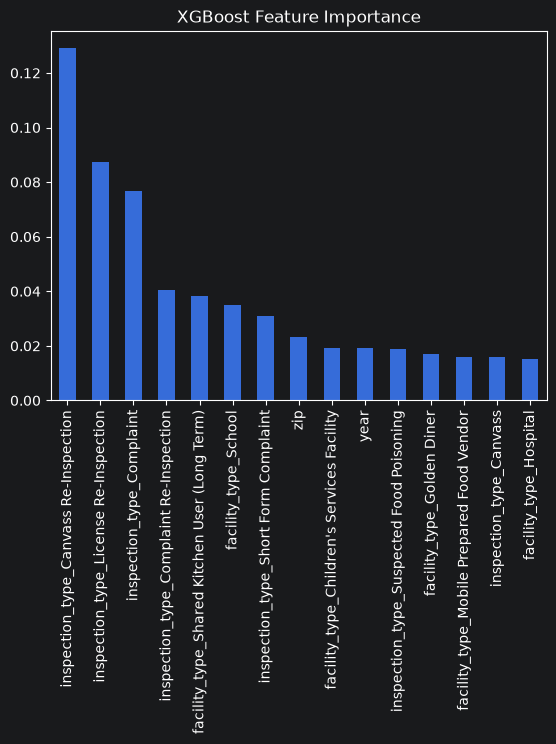

In [104]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(15).plot(kind="bar")

plt.title("XGBoost Feature Importance")
plt.show()

---
BACKUP
---

----


### Risk Ranking

In [105]:
df_clean = df.dropna(subset=["facility_type", "results"])

risk_map = {
    "Fail": 1.0,
    "Pass w/ Conditions": 0.5,
    "Pass": 0.0
}

df_clean["risk_score"] = df_clean["results"].map(risk_map)

In [106]:
ranking_risk = (
    df_clean.groupby("facility_type")["risk_score"]
    .mean()
    .sort_values(ascending=False)
)

counts = df_clean["facility_type"].value_counts()

ranking_risk_filtered = ranking_risk[counts >= 30]

ranking_risk_filtered.head(15)

facility_type
Liquor                             0.342593
TAVERN                             0.320513
Long Term Care                     0.314773
Grocery Store                      0.308577
Bakery                             0.308475
Restaurant                         0.295040
School                             0.289371
Mobile Food Preparer               0.277448
Shared Kitchen                     0.269663
Daycare (Under 2 Years)            0.265625
BANQUET HALL                       0.250000
Daycare Combo 1586                 0.241379
UNKNOWN                            0.236842
Daycare Above and Under 2 Years    0.227679
Daycare (2 - 6 Years)              0.219780
Name: risk_score, dtype: float64

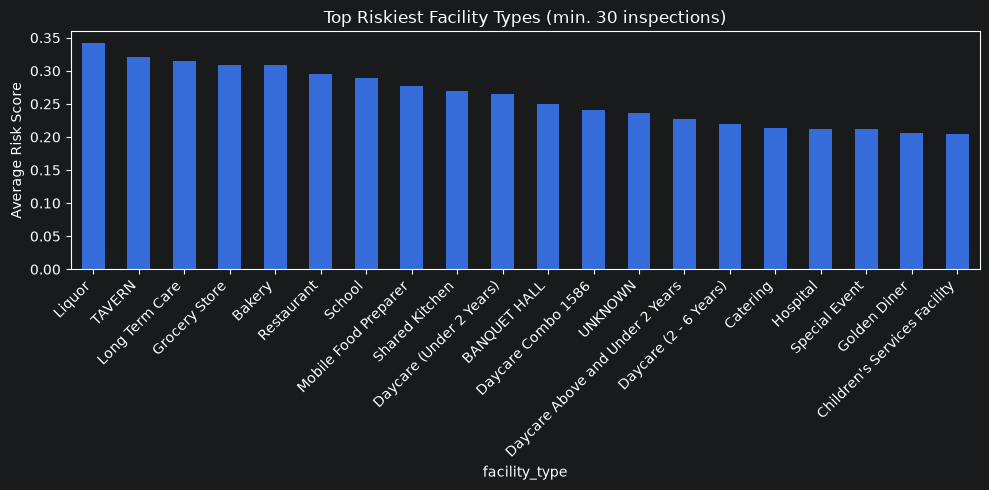

In [107]:
import matplotlib.pyplot as plt

ranking_risk_filtered.head(20).plot(kind="bar", figsize=(10,5))

plt.title("Top Riskiest Facility Types (min. 30 inspections)")
plt.ylabel("Average Risk Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Month

<Axes: xlabel='month'>

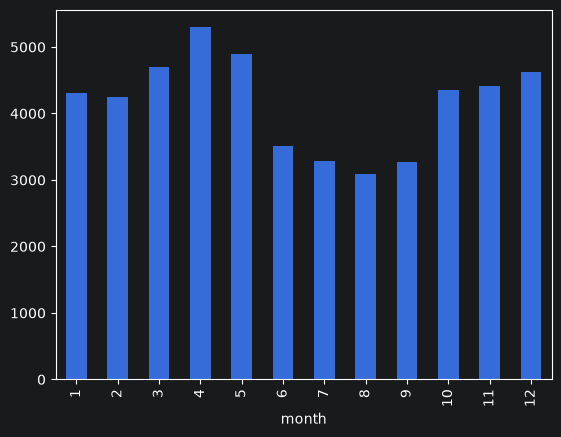

In [108]:
df["month"].value_counts().sort_index().plot(kind="bar")

## Year

<Axes: xlabel='year'>

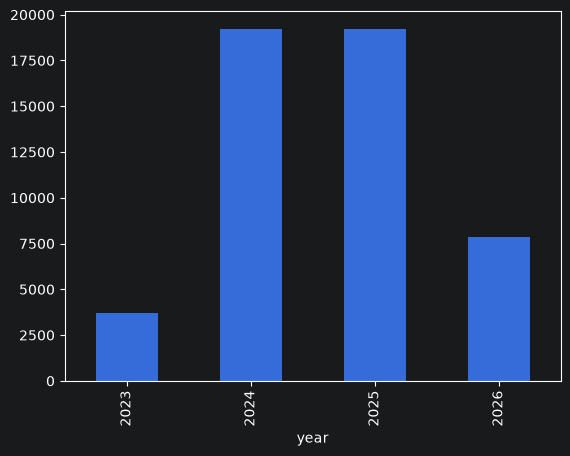

In [109]:

df["year"].value_counts().sort_index().plot(kind="bar")

## Inspection / Weekdays

<Axes: xlabel='weekday'>

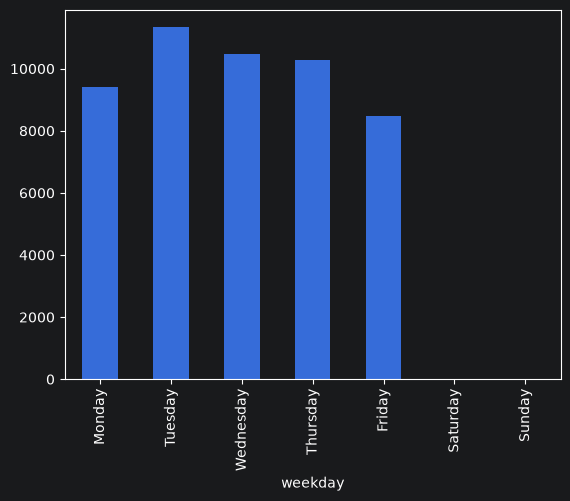

In [110]:
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

df["weekday"] = pd.Categorical(df["weekday"], categories=order, ordered=True)

df["weekday"].value_counts().sort_index().plot(kind="bar")

## Inspection Type

<Axes: xlabel='inspection_type'>

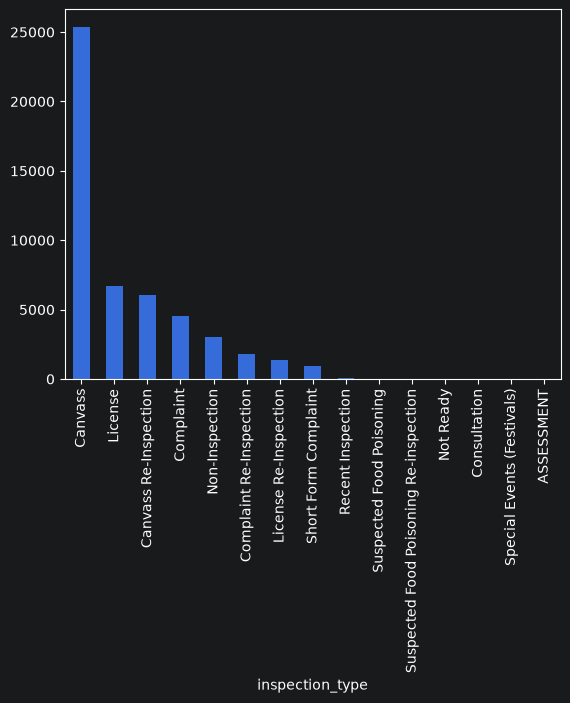

In [111]:
## Licence Type
df["inspection_type"].value_counts()
df["inspection_type"].value_counts().plot(kind="bar")

## Inspection Type vs Result

In [112]:
pd.crosstab(df["inspection_type"], df["results"])

results,Business Not Located,Fail,No Entry,Not Ready,Out of Business,Pass,Pass w/ Conditions
inspection_type,,,,,,,
ASSESSMENT,0,1,0,0,0,0,0
Canvass,6,5011,102,6,3446,12938,3855
Canvass Re-Inspection,0,618,44,1,7,5040,363
Complaint,0,1478,349,0,13,1856,847
Complaint Re-Inspection,0,243,19,0,5,1419,121
Consultation,0,0,0,0,0,2,0
License,1,1309,108,1158,3,3436,691
License Re-Inspection,0,101,4,2,2,1111,170
Non-Inspection,4,2,2958,18,18,4,3


<Axes: xlabel='inspection_type'>

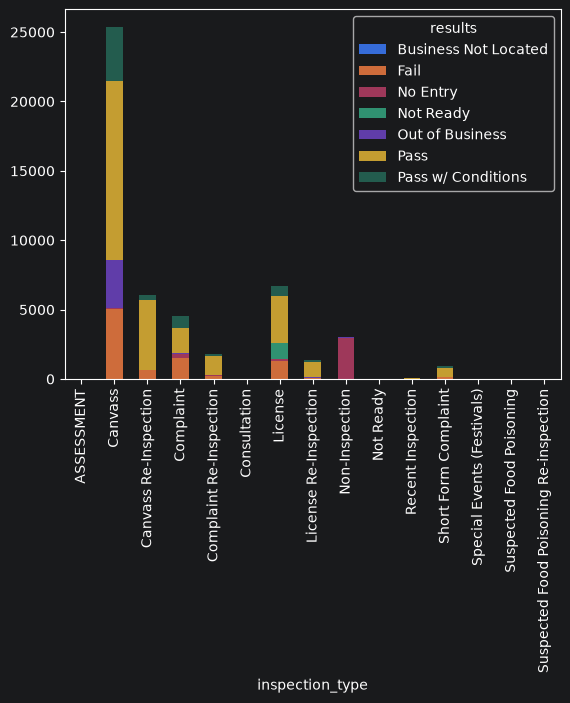

In [113]:
pd.crosstab(df["inspection_type"], df["results"]).plot(kind="bar", stacked=True)

## Fails pro Ort

In [114]:
fails = df[df["results"] == "Fail"]

fails_by_zip = fails["zip"].value_counts()
fails_by_zip.head(20)

zip
60616.0    395
60622.0    385
60614.0    344
60611.0    320
60608.0    316
60625.0    310
60639.0    309
60654.0    302
60647.0    293
60657.0    264
60617.0    263
60607.0    261
60620.0    239
60632.0    211
60612.0    196
60651.0    194
60619.0    186
60613.0    185
60618.0    180
60660.0    176
Name: count, dtype: int64

In [115]:
zip_stats = df.groupby("zip").agg(
    total=("inspection_id", "count"),
    fails=("results", lambda x: (x == "Fail").sum())
)

zip_stats["fail_rate"] = zip_stats["fails"] / zip_stats["total"]

zip_stats.sort_values("fail_rate", ascending=False).head(20)

,total,fails,fail_rate
zip,,,
60475.0,1,1,1.000000
60827.0,34,11,0.323529
60620.0,882,239,0.270975
60636.0,543,145,0.267035
60617.0,1014,263,0.259369
60660.0,681,176,0.258443
60616.0,1661,395,0.237809
60624.0,474,112,0.236287
60651.0,826,194,0.234867


<Axes: xlabel='zip'>

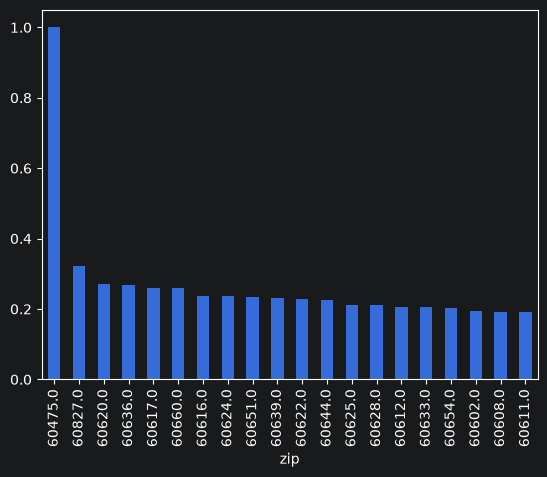

In [116]:
zip_stats.sort_values("fail_rate", ascending=False)["fail_rate"].head(20).plot(
    kind="bar"
)

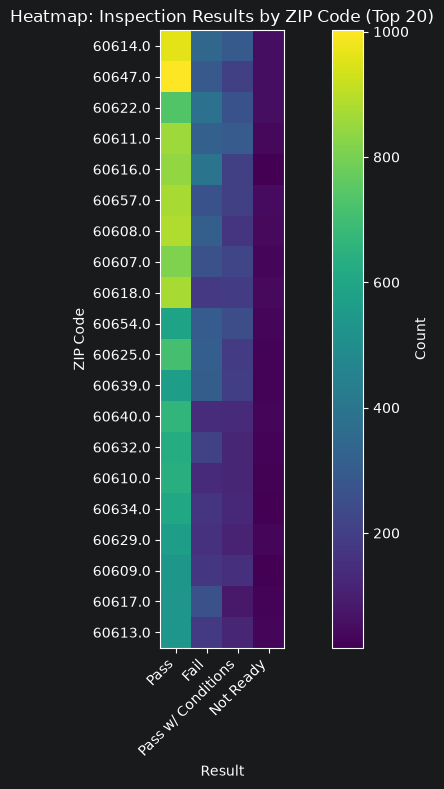

In [117]:
# Crosstab: ZIP vs Inspection Result
ct = pd.crosstab(df["zip"], df["results"])

# Optional: nur Top 20 ZIPs (nach Anzahl Inspections)
top_zips = df["zip"].value_counts().head(20).index
ct = ct.loc[top_zips]

# Spalten sortieren (falls vorhanden)
preferred_order = ["Pass", "Fail", "Pass w/ Conditions", "Not Ready"]
ct = ct[[c for c in preferred_order if c in ct.columns]]

# Heatmap
plt.figure(figsize=(10, 8))
plt.imshow(ct.values)

plt.xticks(range(len(ct.columns)), ct.columns, rotation=45, ha="right")
plt.yticks(range(len(ct.index)), ct.index)

plt.title("Heatmap: Inspection Results by ZIP Code (Top 20)")
plt.xlabel("Result")
plt.ylabel("ZIP Code")

plt.colorbar(label="Count")

plt.tight_layout()
plt.show()

### Text Analysis of Violations

In [118]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud

In [119]:
text = " ".join(
    df["violations"]
    .fillna("")
    .astype(str)
)

words = re.findall(r"\b[a-z]+\b", text.lower())
Counter(words).most_common(30)

[('and', 206843),
 ('to', 155854),
 ('food', 152671),
 ('comments', 152152),
 ('the', 146035),
 ('in', 143614),
 ('instructed', 109292),
 ('observed', 106141),
 ('of', 99535),
 ('clean', 81291),
 ('on', 74481),
 ('maintain', 65628),
 ('at', 63040),
 ('all', 60226),
 ('must', 54376),
 ('properly', 50723),
 ('area', 50169),
 ('prep', 43535),
 ('a', 39646),
 ('installed', 39599),
 ('facilities', 38029),
 ('used', 36883),
 ('for', 36025),
 ('no', 35904),
 ('maintained', 34785),
 ('surfaces', 34464),
 ('sink', 34338),
 ('with', 34192),
 ('priority', 33823),
 ('provide', 33442)]

In [120]:
stop_words = set(ENGLISH_STOP_WORDS)
words = [w for w in words if w not in stop_words]

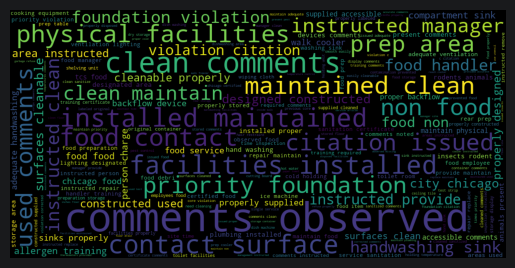

In [121]:
wordcloud = WordCloud(
    width=1000,
    height=500
).generate(" ".join(words))

plt.imshow(wordcloud)
plt.axis("off")
plt.show()

Top Violation Codes

In [122]:
codes = []

for row in df["violations"].dropna():
    codes.extend(re.findall(r"(\d+)\.", row))

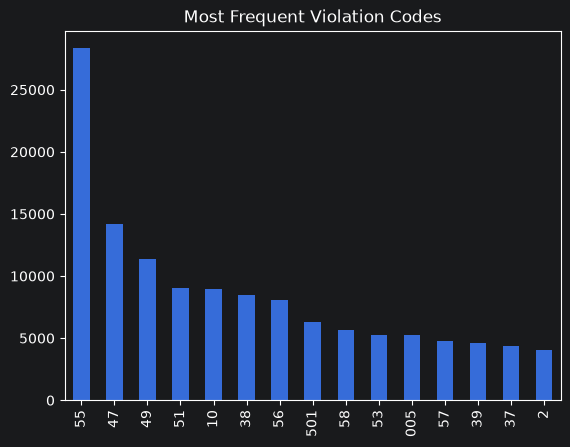

In [123]:
pd.Series(codes).value_counts().head(15).plot(kind="bar")
plt.title("Most Frequent Violation Codes")
plt.show()

In [124]:
df_clean["num_violations"] = df_clean["violations"].fillna("").apply(
    lambda x: x.count("|") + 1 if x != "" else 0
)


## Key Findings

- Missing values in violations are informative rather than random
- Inspection results are imbalanced
- Violation reports are highly skewed
- Several violation categories occur frequently
- Text features may help prediction models

## Number of Violations

In [125]:
df["num_violations"] = df["violations"].fillna("").apply(
    lambda x: x.count("|") + 1 if x != "" else 0
)

df["num_violations"].describe()

count    50000.000000
mean         3.034000
std          3.555168
min          0.000000
25%          0.000000
50%          2.000000
75%          5.000000
max         40.000000
Name: num_violations, dtype: float64

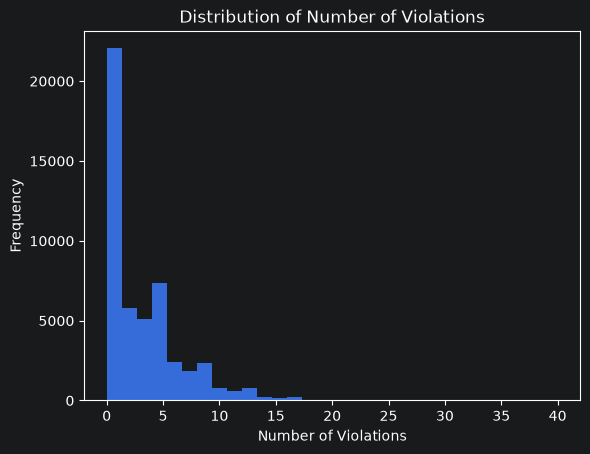

In [126]:
df["num_violations"].plot(kind="hist", bins=30)
plt.title("Distribution of Number of Violations")
plt.xlabel("Number of Violations")
plt.show()

### Extract Violation Codes

In [127]:
### Extract Violation Codes

def extract_codes(text):
    if pd.isna(text):
        return []
    return re.findall(r"(\d+)\.", text)


df["violation_codes"] = df["violations"].apply(extract_codes)

df["violation_codes"].head(100)

0                                                    []
1     [3, 010, 5, 005, 36, 005, 49, 53, 55, 60, 2612...
2                                                    []
3                                          [36, 49, 55]
4                                                    []
                            ...                        
95             [3, 102, 010, 10, 301, 53, 501, 54, 501]
96    [23, 1, 005, 25, 005, 38, 49, 53, 53, 55, 55, 57]
97    [41, 304, 44, 903, 49, 601, 55, 501, 55, 501, ...
98                             [16, 23, 49, 55, 55, 56]
99                                                   []
Name: violation_codes, Length: 100, dtype: object

Preparation for ML

In [128]:
### One-Hot Encode Violation Codes

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

violation_matrix = pd.DataFrame(
    mlb.fit_transform(df["violation_codes"]),
    columns=[f"viol_{c}" for c in mlb.classes_],
    index=df.index
)

df_ml = pd.concat([df, violation_matrix], axis=1)

df_ml.shape

(50000, 657)

Target for Prediction

In [129]:
df_ml = df_ml[df_ml["results"].isin(["Pass", "Fail", "Pass w/ Conditions"])].copy()

df_ml["failed"] = (
    df_ml["results"] == "Fail"
).astype(int)

df_ml["failed"].value_counts()

failed
0    32787
1     8910
Name: count, dtype: int64

In [130]:
records = []

for text in df["violations"].dropna():
    matches = re.findall(
        r'(\d+)\.\s*(.*?)\s*- Comments:',
        text
    )

    for code, description in matches:
        records.append([code, description.strip()])

violations_lookup = pd.DataFrame(
    records,
    columns=["code", "description"]
).drop_duplicates()

violations_lookup.head(20)

,code,description
0,3,"MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL EMPL..."
1,010,CITATION ISSUED. | 5. PROCEDURES FOR RESPONDIN...
2,005,CITATION ISSUED. | 36. THERMOMETERS PROVIDED &...
3,005,CITATION ISSUED. | 49. NON-FOOD/FOOD CONTACT S...
4,53,"TOILET FACILITIES: PROPERLY CONSTRUCTED, SUPPL..."
5,55,"PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN"
6,60,PREVIOUS CORE VIOLATION CORRECTED
7,36,THERMOMETERS PROVIDED & ACCURATE
8,49,NON-FOOD/FOOD CONTACT SURFACES CLEAN
10,47,"FOOD & NON-FOOD CONTACT SURFACES CLEANABLE, PR..."


## Features for ML

risk
facility_type
inspection_type
zip


num_violations
violations_lenght
num_unique_codes


top_violation codes


-----------------------


In [131]:
df["city"].value_counts()
df["city"] = df["city"].fillna("Unknown")
df["city"].value_counts()

city
CHICAGO            49755
Chicago               98
Unknown               50
chicago               24
EVANSTON               9
CCHICAGO               9
CHICAGOO               7
OAK PARK               4
BERWYN                 4
312CHICAGO             4
MERRIVILLE             3
CHICAGO.               3
RIPON                  2
SKOKIE                 2
CH                     2
CHICAGOCHICAGO         2
CHicago                2
NAPERVILLE             2
BOLINGBROOK            1
ELMHURST               1
CAROL STREAM           1
AURORA                 1
TORRANCE               1
LOS ANGELES            1
BALDWIN PARK           1
MOUNT PROSPECT         1
GRAYSLAKE              1
BROOKFIELD             1
HAMMOND                1
MERRILLVILLE           1
BURBANK                1
EVERGREEN              1
MATTESON               1
HIGHLAND PARK          1
PLAINFIELD             1
WESTERN SPRINGS        1
Name: count, dtype: int64

In [132]:
df["risk"].value_counts(dropna=False)

risk
Risk 1 (High)      40156
Risk 2 (Medium)     7293
Risk 3 (Low)        2487
All                   50
NaN                   14
Name: count, dtype: int64

<Axes: >

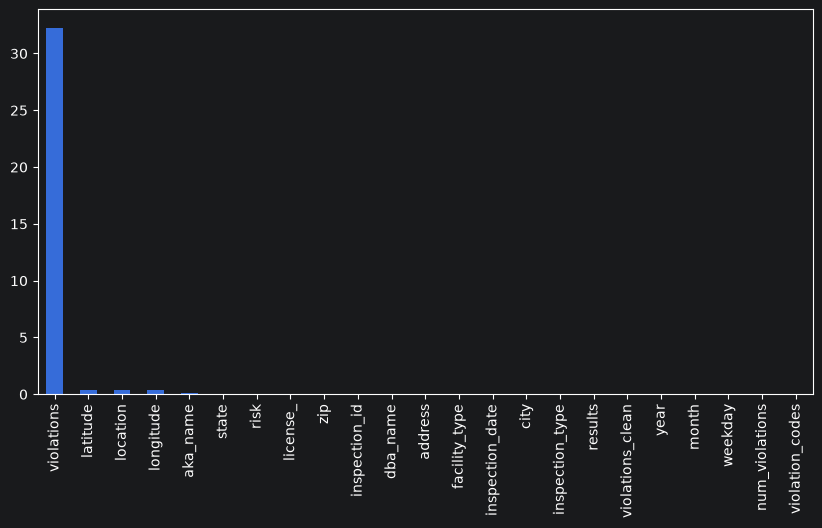

In [133]:
missing_percent = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing_percent.plot(kind="bar", figsize=(10,5))

<Axes: >

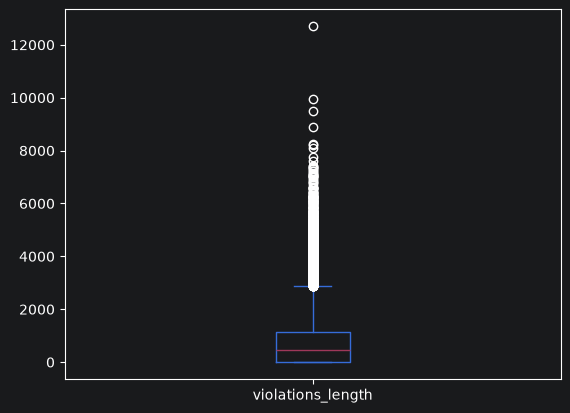

In [134]:
df['violations_length'] = (
    df['violations']
    .fillna("")
    .str.len()
)

df["violations_length"].plot(kind="box")

In [135]:
df["violations_length"].describe()

count    50000.000000
mean       775.804260
std        978.396861
min          0.000000
25%          0.000000
50%        445.000000
75%       1157.000000
max      12706.000000
Name: violations_length, dtype: float64

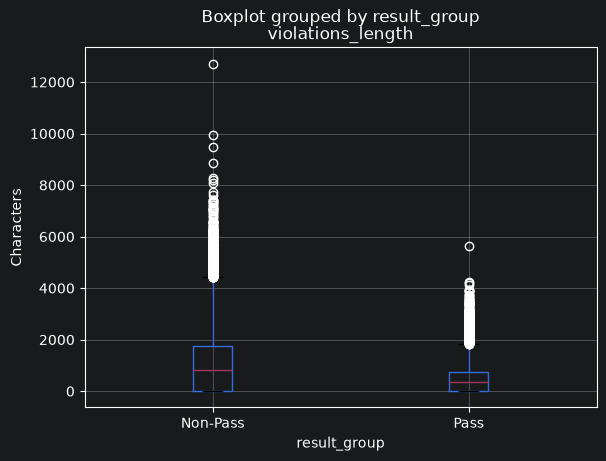

In [136]:
df["result_group"] = df["results"].apply(
    lambda x: "Pass" if x == "Pass" else "Non-Pass"
)

df.boxplot(column="violations_length", by="result_group")
plt.ylabel("Characters")
plt.show()

sehr viele Werte nahe 0, viele Outliers, da viele Pass Inspektionen keine Violations enthalten

A substantial portion of inspections have no recorded violations, which creates a large concentration of values near zero.

------------------